In [1]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Starting the project...")

# loading the datasets from my computer
fake_news = pd.read_csv("Fake.csv")
true_news = pd.read_csv("True.csv")

print("Data loaded! Adding labels now...")

# fake is 0, real is 1
fake_news["label"] = 0
true_news["label"] = 1

# merging them together
my_data = pd.concat([fake_news, true_news], ignore_index=True)

# shuffle data so the AI doesn't memorize the order
my_data = my_data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Data shape is:", my_data.shape)

# cleaning the text because computers hate messy symbols
def clean_my_text(text):
    text = str(text).lower() # make lower case
    text = re.sub(r'http\S+', '', text) # delete website links
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuation like ! and ?
    text = re.sub(r'\d+', '', text) # remove numbers
    return text.strip()

print("Cleaning text... this might take a minute...")
my_data["text"] = my_data["text"].apply(clean_my_text)
print("Done with cleaning!")

# getting ready for the AI
X = my_data["text"]
y = my_data["label"]

print("Translating words to numbers using TF-IDF...")
# translating words to numbers
my_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_numbers = my_vectorizer.fit_transform(X)

print("Splitting data into train and test groups...")
# split 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_numbers, y, test_size=0.20, random_state=42)

print("Setting up the 4 Machine Learning Models...")
my_models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, random_state=42) # reduced iterations so it runs faster
}

accuracy_results = []
model_names = []

for name, model in my_models.items():
    print("\n=========================================")
    print("Training", name, "...")
    model.fit(X_train, y_train)
    guesses = model.predict(X_test)
    
    acc = accuracy_score(y_test, guesses)
    pre = precision_score(y_test, guesses)
    rec = recall_score(y_test, guesses)
    f1 = f1_score(y_test, guesses)
    
    accuracy_results.append(acc)
    model_names.append(name)
    
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))

print("\nProject finished successfully!")


Starting the project...
Data loaded! Adding labels now...
Data shape is: (44898, 5)
Cleaning text... this might take a minute...
Done with cleaning!
Translating words to numbers using TF-IDF...
Splitting data into train and test groups...
Setting up the 4 Machine Learning Models...

Training KNN ...
Accuracy: 0.7076
Precision: 0.9168
Recall: 0.4234
F1 Score: 0.5793

Training Logistic Regression ...
Accuracy: 0.9833
Precision: 0.9784
Recall: 0.9867
F1 Score: 0.9825

Training Random Forest ...
Accuracy: 0.9951
Precision: 0.9962
Recall: 0.9934
F1 Score: 0.9948

Training Neural Network ...
Accuracy: 0.9875
Precision: 0.9876
Recall: 0.9862
F1 Score: 0.9869

Project finished successfully!


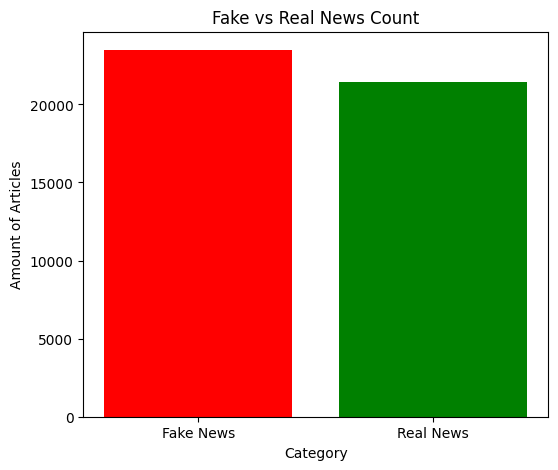

In [2]:
import matplotlib.pyplot as plt

# plot a simple bar chart of the Dataset
my_labels = ['Fake News', 'Real News']
counts = my_data['label'].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(my_labels, counts, color=['red','green'])
plt.title("Fake vs Real News Count")
plt.xlabel("Category")
plt.ylabel("Amount of Articles")

plt.show()

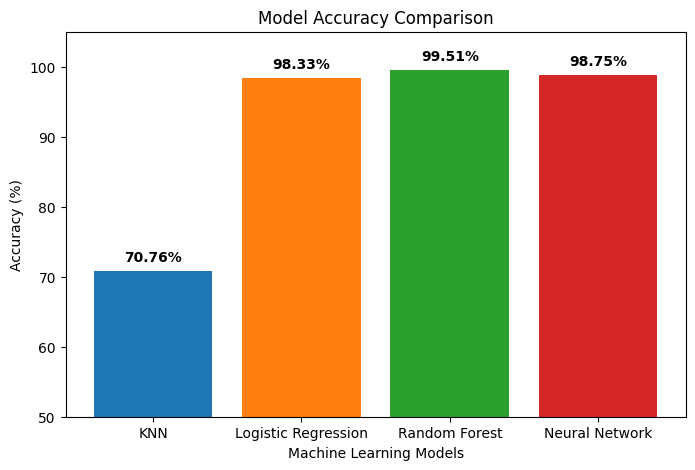

In [3]:
# plot the accuracies of our 4 models
plt.figure(figsize=(8,5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(model_names, [acc * 100 for acc in accuracy_results], color=colors)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.ylim(50, 105)

# Add the percentages on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{round(yval, 2)}%", ha='center', va='bottom', fontweight='bold')

plt.show()